In [1]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
!unzip -q rps.zip -d rps

In [2]:
import os

print(os.listdir("rps"))

['rps']


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# write the config for data augumentatiom
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2

)

In [4]:
# apply the data augumentation
ds_gen  = train_datagen.flow_from_directory(
    "rps/rps",
    target_size=(224,224),
    batch_size=32,
    subset="training",
    class_mode='categorical',
    seed=42

)

Found 2016 images belonging to 3 classes.


In [30]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen = val_datagen.flow_from_directory(
    "rps/rps",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    seed=42,
    shuffle=False
)

Found 504 images belonging to 3 classes.


In [6]:
from tensorflow import keras
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()
model.add(Conv2D(64,(3,3),padding="same",activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),padding="same",activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [10]:
history = model.fit(ds_gen,validation_data=val_gen,epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 570ms/step - accuracy: 0.4678 - loss: 1.2624 - val_accuracy: 0.8393 - val_loss: 0.5706
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 498ms/step - accuracy: 0.8656 - loss: 0.3727 - val_accuracy: 0.9167 - val_loss: 0.3586
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 511ms/step - accuracy: 0.9266 - loss: 0.2121 - val_accuracy: 0.8869 - val_loss: 0.3589
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 489ms/step - accuracy: 0.9603 - loss: 0.1181 - val_accuracy: 0.6369 - val_loss: 0.7960
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.9792 - loss: 0.0625 - val_accuracy: 0.9107 - val_loss: 0.2221
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step - accuracy: 0.9851 - loss: 0.0460 - val_accuracy: 0.8333 - val_loss: 0.3621
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 494ms/step - accuracy: 0.9792 - loss: 0.0611 - val_accuracy: 0.7698 - val_loss: 0.3610
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 494ms/step - accuracy: 0.9836 - loss: 0.0472 - val_accu

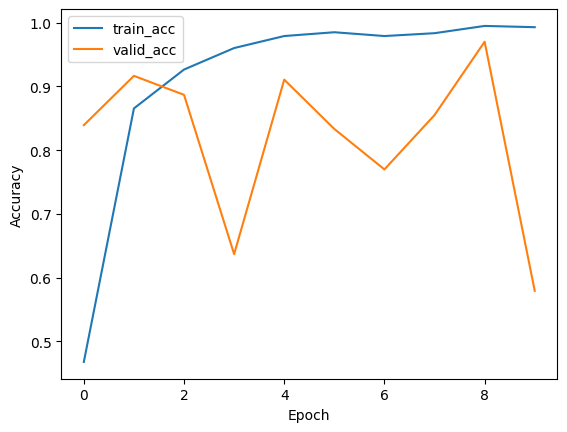

In [11]:
import matplotlib.pyplot as plt
# accuracy curves
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='valid_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


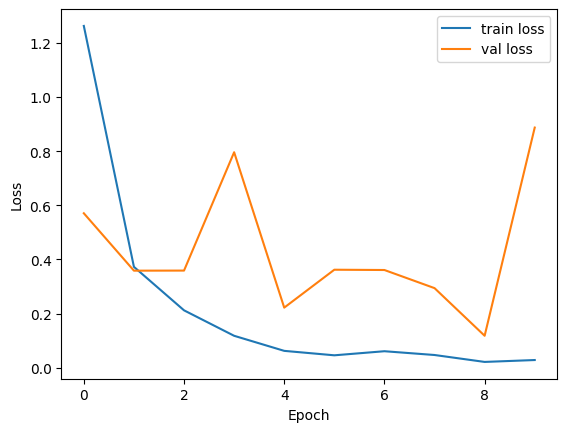

In [12]:
#loss curves
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
model2 = Sequential()
model2.add(Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(224,224,3)))
model2.add(MaxPooling2D(2,2))
model2.add(Conv2D(64,(3,3),padding="same",activation="relu"))
model2.add(MaxPooling2D(2,2))
model2.add(Flatten())
model2.add(Dense(64,activation='relu'))
model2.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model2.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [20]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=5,verbose=1,restore_best_weights=True)
history = model2.fit(ds_gen,validation_data=val_gen,epochs=10,callbacks=[early_stop])

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 494ms/step - accuracy: 0.5253 - loss: 1.3225 - val_accuracy: 0.8710 - val_loss: 0.5165
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 499ms/step - accuracy: 0.9092 - loss: 0.2764 - val_accuracy: 0.8909 - val_loss: 0.3059
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 480ms/step - accuracy: 0.9732 - loss: 0.0983 - val_accuracy: 0.7540 - val_loss: 0.5890
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 487ms/step - accuracy: 0.9851 - loss: 0.0543 - val_accuracy: 0.8651 - val_loss: 0.3308
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 487ms/step - accuracy: 0.9831 - loss: 0.0628 - val_accuracy: 0.7143 - val_loss: 0.6054
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 474ms/step - accuracy: 0.9792 - loss: 0.0629 - val_accuracy: 0.9444 - val_loss: 0.1800
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 495ms/step - accuracy: 0.9931 - loss: 0.0269 - val_accuracy: 0.9048 - val_loss: 0.3439
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 481ms/step - accuracy: 0.9876 - loss: 0.0369 - val_accu

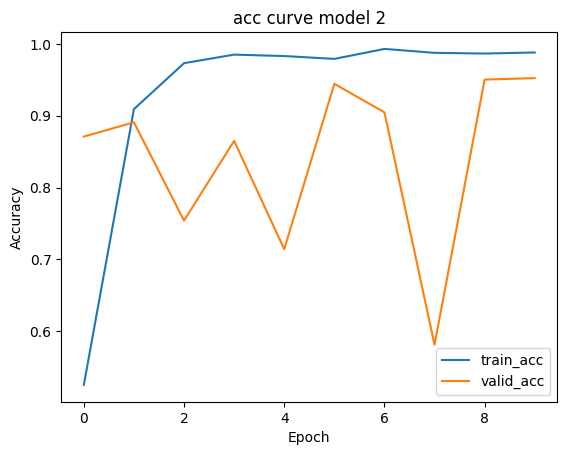

In [21]:
import matplotlib.pyplot as plt
# accuracy curves
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='valid_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("acc curve model 2")
plt.legend()
plt.legend()
plt.show()


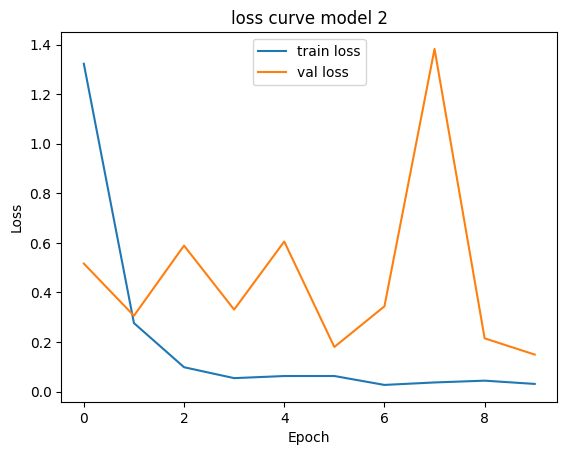

In [22]:
#loss curves
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("loss curve model 2")
plt.legend()
plt.show()

In [31]:
pred = model2.predict(val_gen)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


In [32]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [33]:
pred_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,

In [34]:
actual_classes = val_gen.classes

In [35]:
from sklearn.metrics import accuracy_score

accuracy_score(actual_classes, pred_classes)

0.9523809523809523

In [37]:
val_gen.class_indices

{'paper': 0, 'rock': 1, 'scissors': 2}

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(actual_classes, pred_classes)
print(cm)

[[168   0   0]
 [ 24 144   0]
 [  0   0 168]]
